# Analyse Exploratoire des Données (EDA) - Prédiction du Temps de Livraison
## Objectif
- Comprendre sa structure du dataset et son contenu
- Comprendre les variables influençant le temps de livraison (`Delivery_Time_min`)  
- Identifier les tendances et relations importantes dans le dataset

## Analyse des données
- Variables numériques : statistiques descriptives et corrélations  
- Variables catégorielles : countplots et boxplots pour étudier leur impact sur la cible  
- Distribution de la cible : histogramme et KDE pour détecter anomalies et valeurs extrêmes  

## Insights
- Variables les plus pertinentes  
- Suppression des valeurs aberrantes (outliers)

In [43]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [44]:
df = pd.read_csv(r"C:\Users\khadija\Desktop\simplon project\Data-IA-Simplon-Maghreb\Brief2- Prédiction Temps de Livraison\Prédiction-Temps-Livraison.csv")

In [45]:
df.head()

,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
0,522,7.93,Windy,Low,Afternoon,Scooter,12,1.0,43
1,738,16.42,Clear,Medium,Evening,Bike,20,2.0,84
2,741,9.52,Foggy,Low,Night,Scooter,28,1.0,59
3,661,7.44,Rainy,Medium,Afternoon,Scooter,5,1.0,37
4,412,19.03,Clear,Low,Morning,Bike,16,5.0,68


In [46]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Order_ID                1000 non-null   int64  
 1   Distance_km             1000 non-null   float64
 2   Weather                 970 non-null    object 
 3   Traffic_Level           970 non-null    object 
 4   Time_of_Day             970 non-null    object 
 5   Vehicle_Type            1000 non-null   object 
 6   Preparation_Time_min    1000 non-null   int64  
 7   Courier_Experience_yrs  970 non-null    float64
 8   Delivery_Time_min       1000 non-null   int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 70.4+ KB


### handling missings values 


In [47]:
df.isna().sum()

Order_ID                   0
Distance_km                0
Weather                   30
Traffic_Level             30
Time_of_Day               30
Vehicle_Type               0
Preparation_Time_min       0
Courier_Experience_yrs    30
Delivery_Time_min          0
dtype: int64

In [48]:
# fill missing value for numérique variable 
df["Courier_Experience_yrs"] = df["Courier_Experience_yrs"] .fillna(df["Courier_Experience_yrs"] .mean())

In [49]:
# fill missing value for catégoriale variable 
catg_cols = df.select_dtypes(include='object').columns
for col in catg_cols :
    df[col] = df[col].fillna(df[col].mode()[0])

In [50]:
# check missing value 
df.isna().sum()

Order_ID                  0
Distance_km               0
Weather                   0
Traffic_Level             0
Time_of_Day               0
Vehicle_Type              0
Preparation_Time_min      0
Courier_Experience_yrs    0
Delivery_Time_min         0
dtype: int64

In [51]:
df.duplicated().sum()

0

## Analyse et visualisations 

In [52]:
# La colonne Order_ID est supprimée car elle n’est pas utile pour l’analyse.
df = df.drop('Order_ID', axis=1)

In [53]:
df.describe()

,Distance_km,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
count,1000.000000,1000.000000,1000.000000,1000.000000
mean,10.059970,16.982000,4.579381,56.732000
std,5.696656,7.204553,2.870301,22.070915
min,0.590000,5.000000,0.000000,8.000000
25%,5.105000,11.000000,2.000000,41.000000
50%,10.190000,17.000000,4.579381,55.500000
75%,15.017500,23.000000,7.000000,71.000000
max,19.990000,29.000000,9.000000,153.000000


### Corrélation entre des variables numériques

In [54]:
# Sélection des colonnes numériques
numer_cols = df.select_dtypes(include='number')

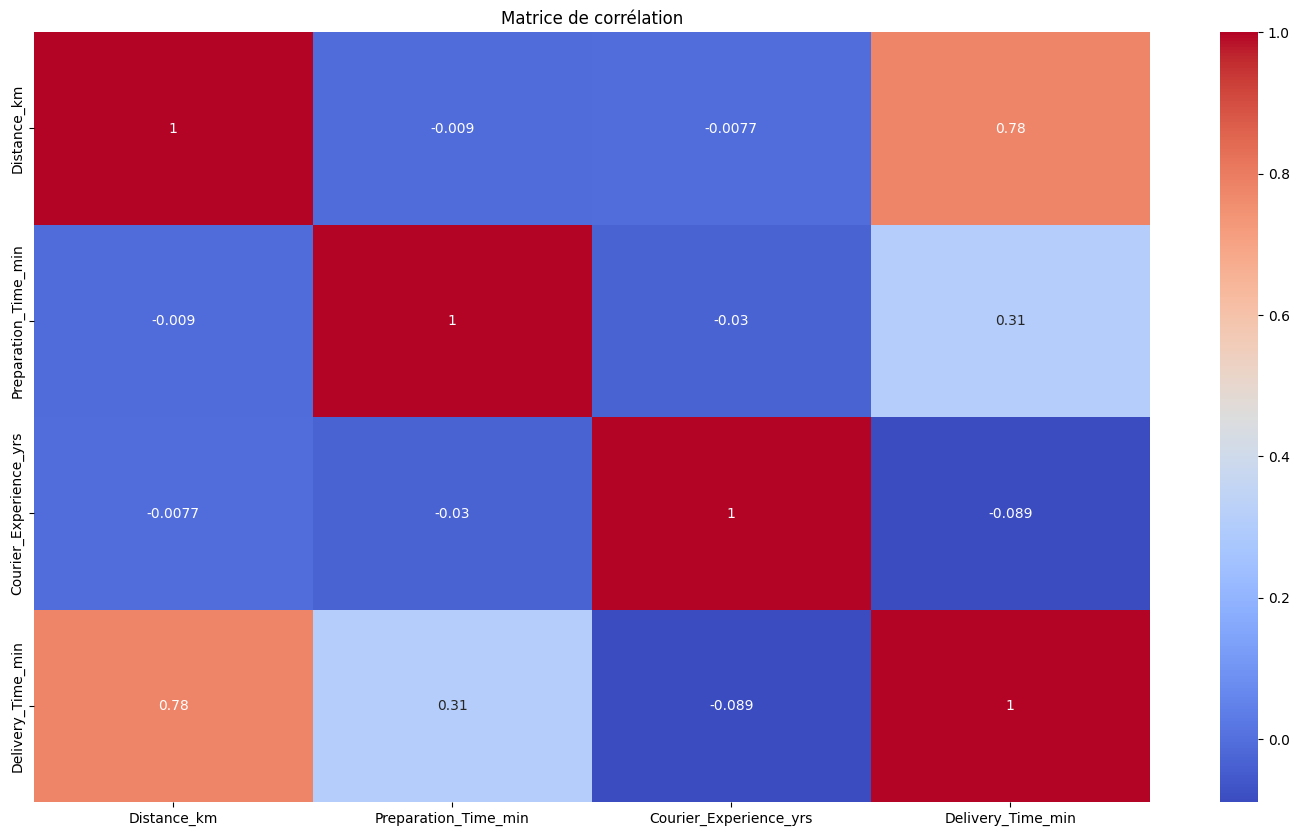

In [55]:
# Calcul de la matrice de corrélation
corr_matrix = numer_cols.corr()

plt.figure(figsize=(18,10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title("Matrice de corrélation")
plt.show()

- La corrélation entre le temps de livraison et la distance entre le restaurant et l’adresse de livraison est de 0,78.Etant proche de 1, cela indique une forte corrélation positive.

### Distribution des variables catégorielle

In [56]:
#  Countplot pour visualiser la distribution des variables catégorielle
def plot_countplot(df, column,title=None):
    
    plt.figure(figsize=(10, 6))
    sns.countplot(x=column, data=df)
    plt.title(title if title else f"Répartition de {column} ")
    plt.xlabel(column)
    plt.ylabel("Nombre de counts")
    plt.show()

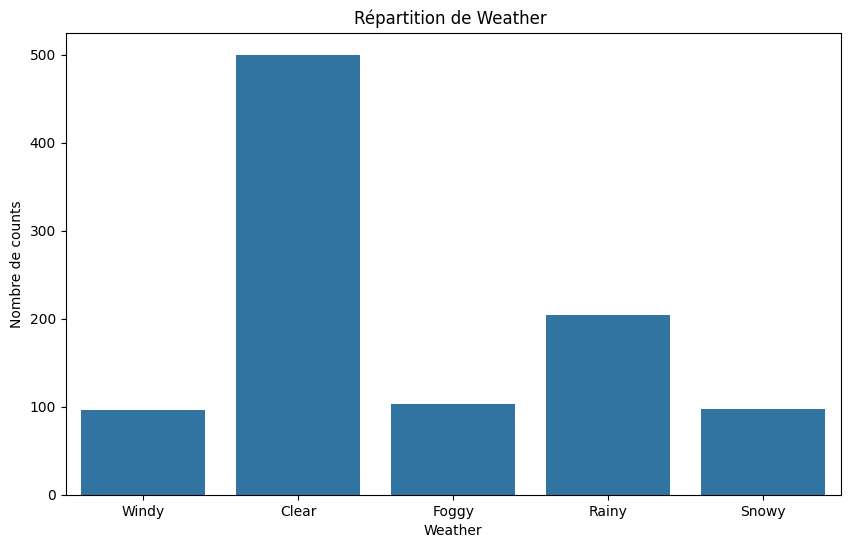

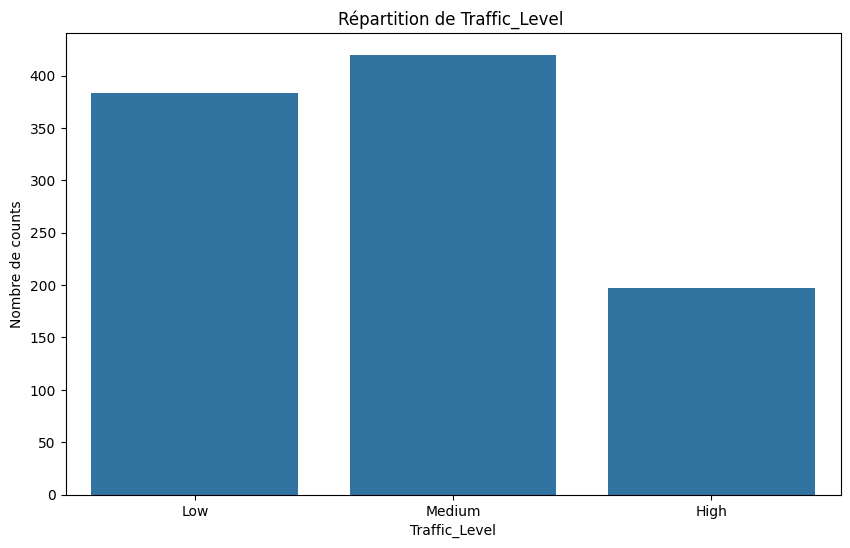

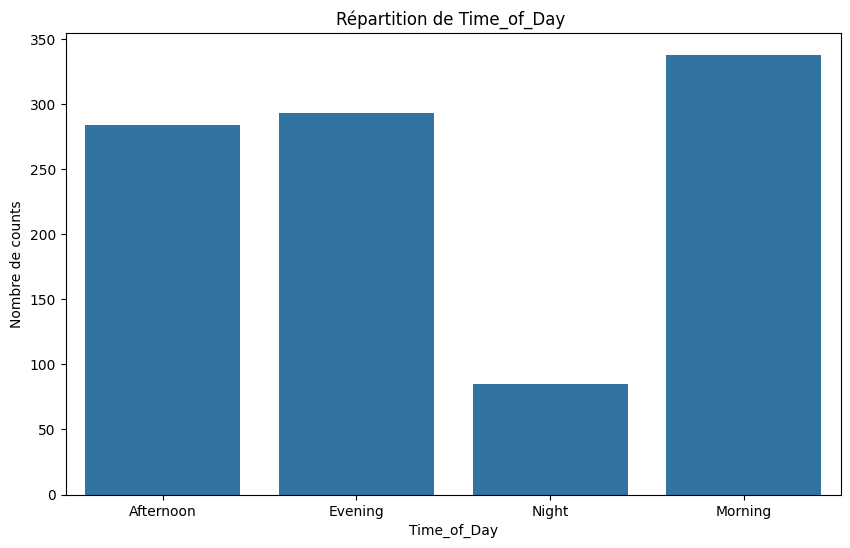

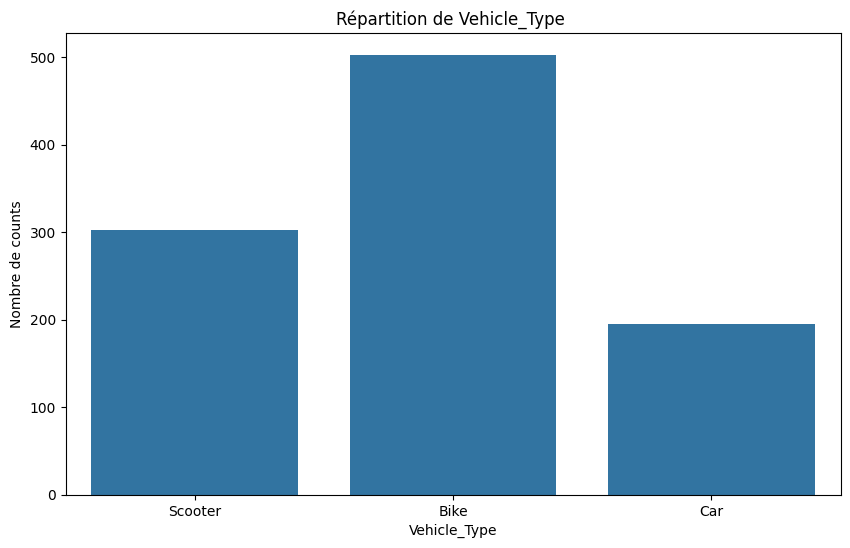

In [57]:
for col in catg_cols:
    plot_countplot(df, column=col)

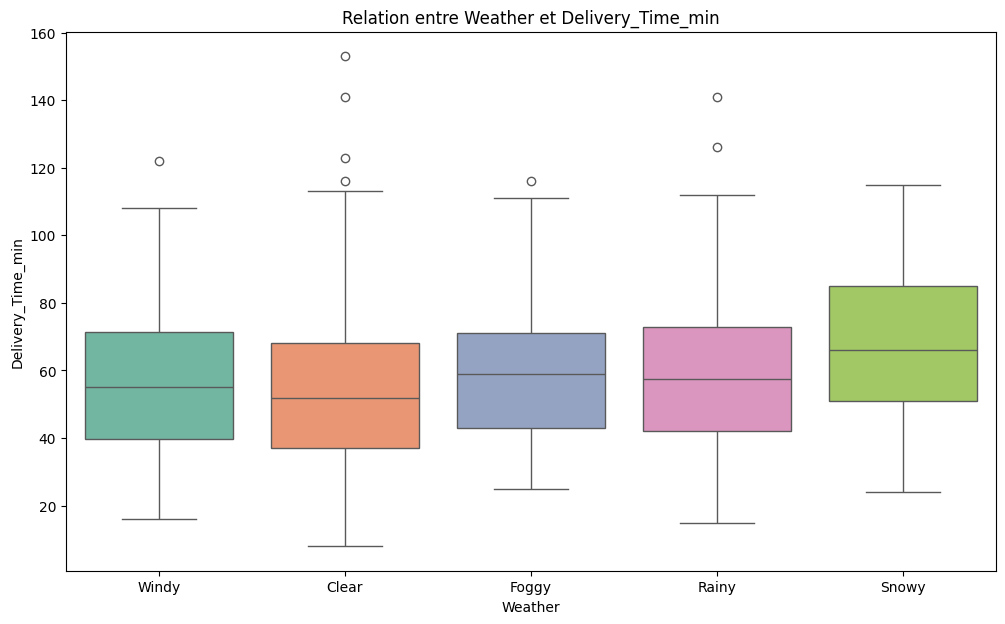

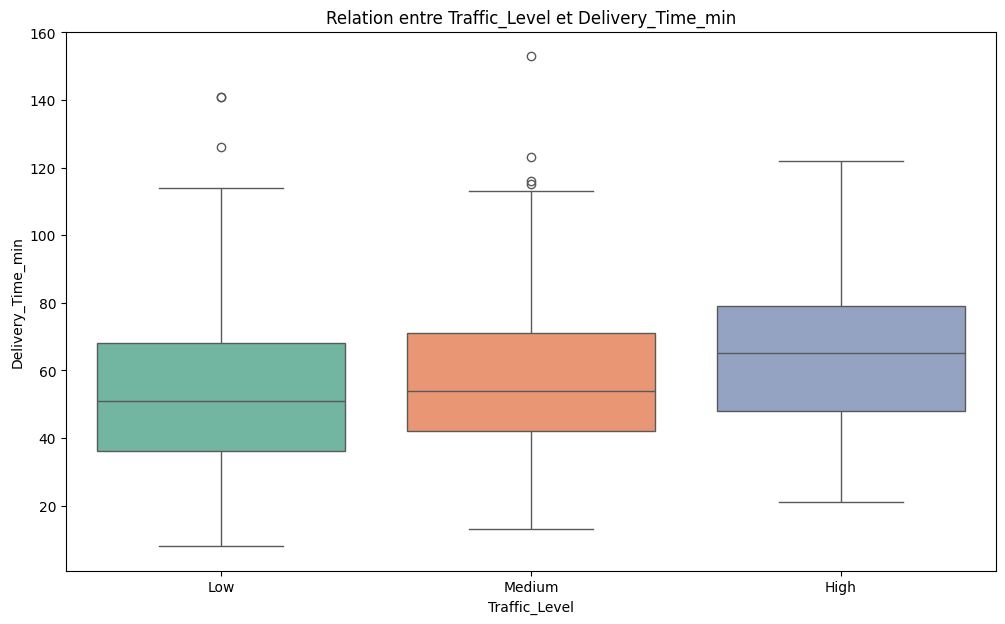

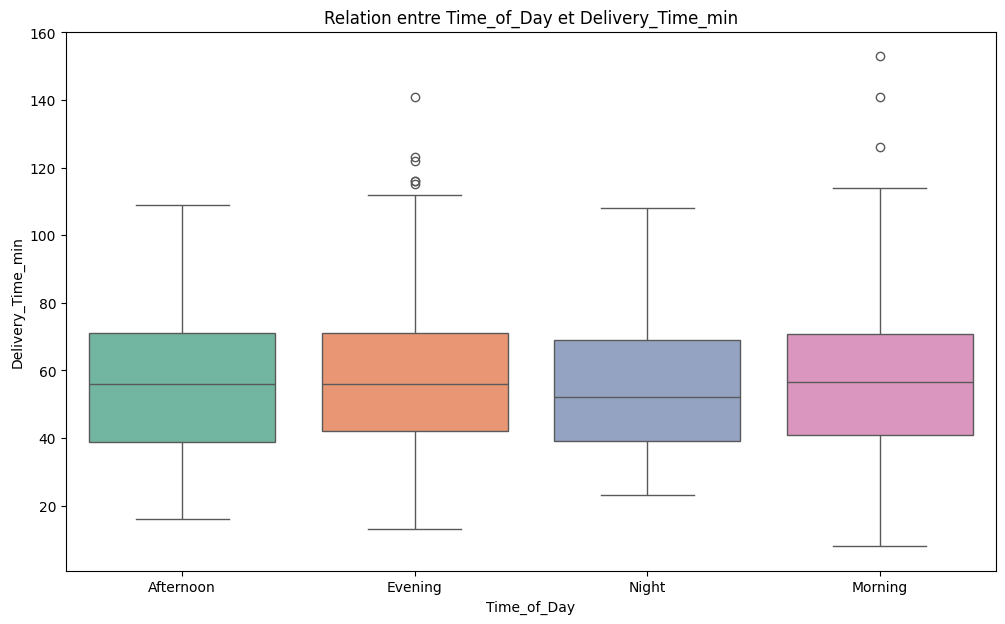

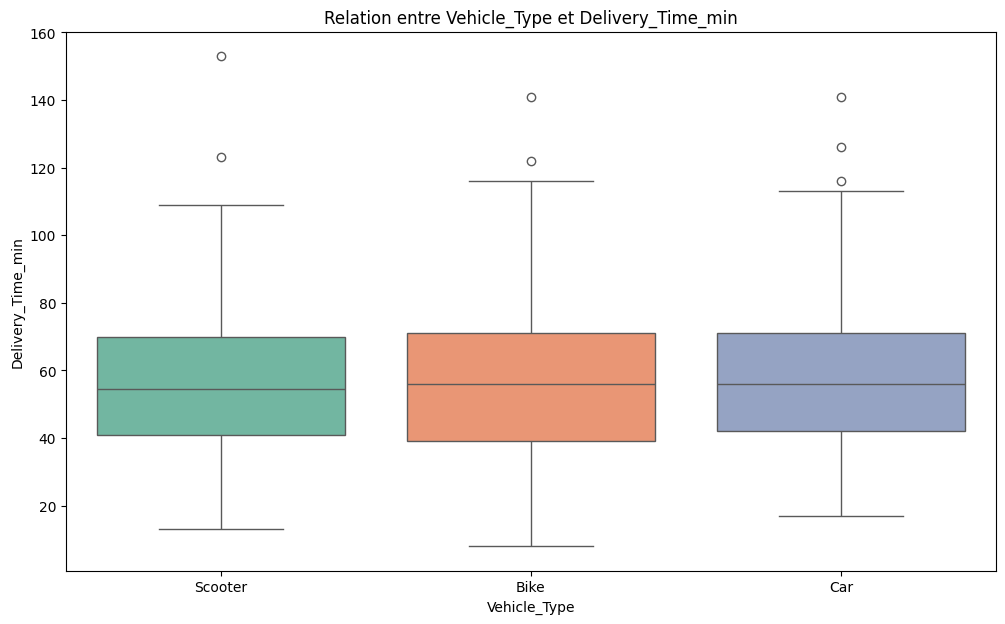

In [58]:
# Boxplots pour visualiser la relation entre la variable cible et les variables catégorielles.
for col in catg_cols : 
    plt.figure(figsize=(12, 7))
    sns.boxplot(data = df ,x= col,y ='Delivery_Time_min', hue=col, palette='Set2')
    plt.title(f'Relation entre {col} et Delivery_Time_min')
    plt.xlabel(col)
    plt.ylabel('Delivery_Time_min')
    plt.show()

D'apres les graphes On conclu que :
  - La temps da la livraison varie selon les conditions méteorologiques 
  - Le niveau de trafic a un impact direct et significatif sur le temps de livraison.
  - Les livraisons sont plus rapides et régulières la nuit, tandis que le matin et le soir présentent plus de retards et de variabilité.
  - Le type de véhicule n’influence pas beaucoup le temps de livraison.

### Analyse de la distribution de la variable cible

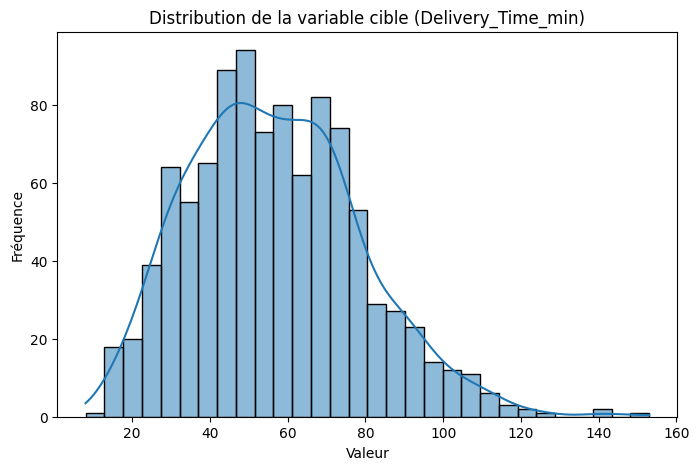

In [59]:
# Analyser la distribution de la variable cibl avec  histogramme
plt.figure(figsize=(8,5))
sns.histplot(df['Delivery_Time_min'], kde=True, bins=30)
plt.title("Distribution de la variable cible (Delivery_Time_min)")
plt.xlabel("Valeur")
plt.ylabel("Fréquence")
plt.show()

- La majorité des livraisons prennent entre 30 et 70 minutes,mais parfois il y a des livraisons qui durent beaucoup plus longtemps.